#### import libraries

In [17]:
from typing import Annotated

from langchain_tavily import TavilySearch
#important because we will convert a function to a tool which will be binded to a llm
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph , START , END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode , tools_condition

# interrupt will forcefully inerupt a workflow so human can provide feedback
from langgraph.types import Command , interrupt

import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
load_dotenv()


True

In [ ]:
class State(TypedDict):
    messages: Annotated[list , add_messages]

graph_builder = StateGraph(State)

llm = llm=ChatGroq(model="openai/gpt-oss-20b")

@tool
# define a tool called human assistance its takes a string and returns a string
def humman_assistance(query: str)->str:
    """Request assistance from human"""
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearch(max_results = 2)
tools = [tool, humman_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state : State):
    message = llm_with_tools.invoke(state["messages"])
    return {"messages" : [message]}

graph_builder.add_node("chatbot" , chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)

graph_builder.add_edge("tools" , "chatbot")
graph_builder.add_edge(START, "chatbot")

In [19]:
memory =  MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

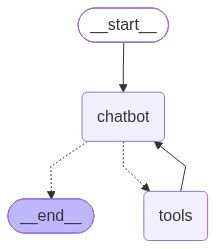

In [20]:
graph

In [21]:
user_input = "I need some expert guidance fro building an ai agent. Could you request assistance for me?"
config = {"configurable": {"thread_id":"1"}}
events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance fro building an ai agent. Could you request assistance for me?


NotFoundError: Error code: 404 - {'error': {'message': 'The model `llama-3.1-8b-instant` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}